# Install libraries and import to Venv

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Functions

def heatmap_correlation(df, text):
    plt.figure(figsize=(10, 8)) 
    sns.heatmap(df, annot= True, fmt='.2f', cmap='coolwarm')
    plt.title(f'Correlation Heatmap of {text}')
    plt.show()

def fill_missing_column(df, target, exclude=[]):
    # Get correlations from the heatmap
    correlations = df.corr()[target].drop(labels=[target] + exclude)
    top_features = correlations.abs().sort_values(ascending=False).head(5).index.tolist()

    # Prepare training and prediction sets
    train = df[df[target].notna() & df[top_features].notna().all(axis=1)]
    test = df[df[target].isna() & df[top_features].notna().all(axis=1)]

    # Only proceed if there is something to train on and predict
    if not train.empty and not test.empty:
        model = LinearRegression()
        model.fit(train[top_features], train[target])
        predictions = model.predict(test[top_features])
        df.loc[test.index, target] = predictions

    return df

# Data Import

In [4]:
df = pd.read_csv('train.csv')
df.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


In [5]:
# limiting the number of decimal places to 2 for better readability
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Exploring data for insights

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18524 entries, 0 to 18523
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18524 non-null  int64  
 1   Time_spent_Alone           17334 non-null  float64
 2   Stage_fear                 16631 non-null  object 
 3   Social_event_attendance    17344 non-null  float64
 4   Going_outside              17058 non-null  float64
 5   Drained_after_socializing  17375 non-null  object 
 6   Friends_circle_size        17470 non-null  float64
 7   Post_frequency             17260 non-null  float64
 8   Personality                18524 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 1.3+ MB


In [7]:
df.describe()

,id,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,18524.00,17334.00,17344.00,17058.00,17470.00,17260.00
mean,9261.50,3.14,5.27,4.04,8.00,4.98
std,5347.56,3.00,2.75,2.06,4.22,2.88
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,4630.75,1.00,3.00,3.00,5.00,3.00
50%,9261.50,2.00,5.00,4.00,8.00,5.00
75%,13892.25,4.00,8.00,6.00,12.00,7.00
max,18523.00,11.00,10.00,7.00,15.00,10.00


### Checking Null Values

In [8]:
df.isnull().sum()

id                              0
Time_spent_Alone             1190
Stage_fear                   1893
Social_event_attendance      1180
Going_outside                1466
Drained_after_socializing    1149
Friends_circle_size          1054
Post_frequency               1264
Personality                     0
dtype: int64

### Checking Unique Values

In [9]:
df.nunique()

id                           18524
Time_spent_Alone                12
Stage_fear                       2
Social_event_attendance         11
Going_outside                    8
Drained_after_socializing        2
Friends_circle_size             16
Post_frequency                  11
Personality                      2
dtype: int64

## Replace stage fear and drained after socializing from Yes/No to 1/0

In [10]:
train_df = df
train_df['Stage_fear'] = train_df['Stage_fear'].replace({'Yes': 1, 'No': 0})
train_df['Drained_after_socializing'] = train_df['Drained_after_socializing'].replace({'Yes': 1, 'No': 0})
train_df['Personality'] = train_df['Personality'].replace({'Extrovert': 1, 'Introvert': 0})  

C:\Users\I748073\AppData\Local\Temp\ipykernel_32072\1831112470.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df['Stage_fear'] = train_df['Stage_fear'].replace({'Yes': 1, 'No': 0})
C:\Users\I748073\AppData\Local\Temp\ipykernel_32072\1831112470.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df['Drained_after_socializing'] = train_df['Drained_after_socializing'].replace({'Yes': 1, 'No': 0})
C:\Users\I748073\AppData\Local\Temp\ipykernel_32072\1831112470.py:4: FutureWarning: Downcasting behavior in `replace` is d

## Selecting only numeric columns

In [11]:
numeric_df = train_df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

In [12]:
numeric_df.describe()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
count,18524.00,17334.00,16631.00,17344.00,17058.00,17375.00,17470.00,17260.00,18524.00
mean,9261.50,3.14,0.24,5.27,4.04,0.23,8.00,4.98,0.74
std,5347.56,3.00,0.43,2.75,2.06,0.42,4.22,2.88,0.44
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,4630.75,1.00,0.00,3.00,3.00,0.00,5.00,3.00,0.00
50%,9261.50,2.00,0.00,5.00,4.00,0.00,8.00,5.00,1.00
75%,13892.25,4.00,0.00,8.00,6.00,0.00,12.00,7.00,1.00
max,18523.00,11.00,1.00,10.00,7.00,1.00,15.00,10.00,1.00


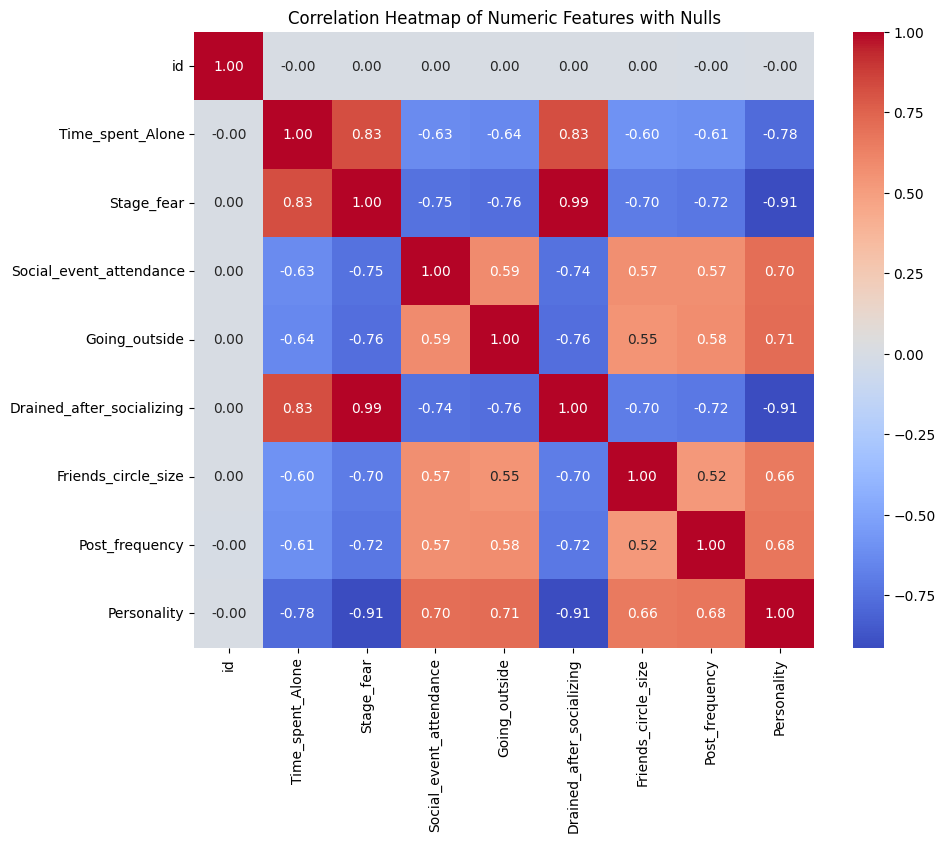

In [13]:
# Calling the function to plot the heatmap
heatmap_correlation(corr_matrix, 'Numeric Features with Nulls')

# Checking difference between nulls

In [14]:
nonulls_df = numeric_df.dropna()
nonulls_df.describe()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
count,10189.00,10189.00,10189.00,10189.00,10189.00,10189.00,10189.00,10189.00,10189.00
mean,9260.69,2.63,0.17,5.68,4.44,0.17,8.50,5.50,0.83
std,5345.62,2.63,0.37,2.60,1.88,0.37,4.07,2.71,0.38
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,4653.00,1.00,0.00,4.00,3.00,0.00,5.00,3.00,1.00
50%,9213.00,2.00,0.00,6.00,5.00,0.00,9.00,6.00,1.00
75%,13878.00,3.00,0.00,8.00,6.00,0.00,12.00,8.00,1.00
max,18523.00,11.00,1.00,10.00,7.00,1.00,15.00,10.00,1.00


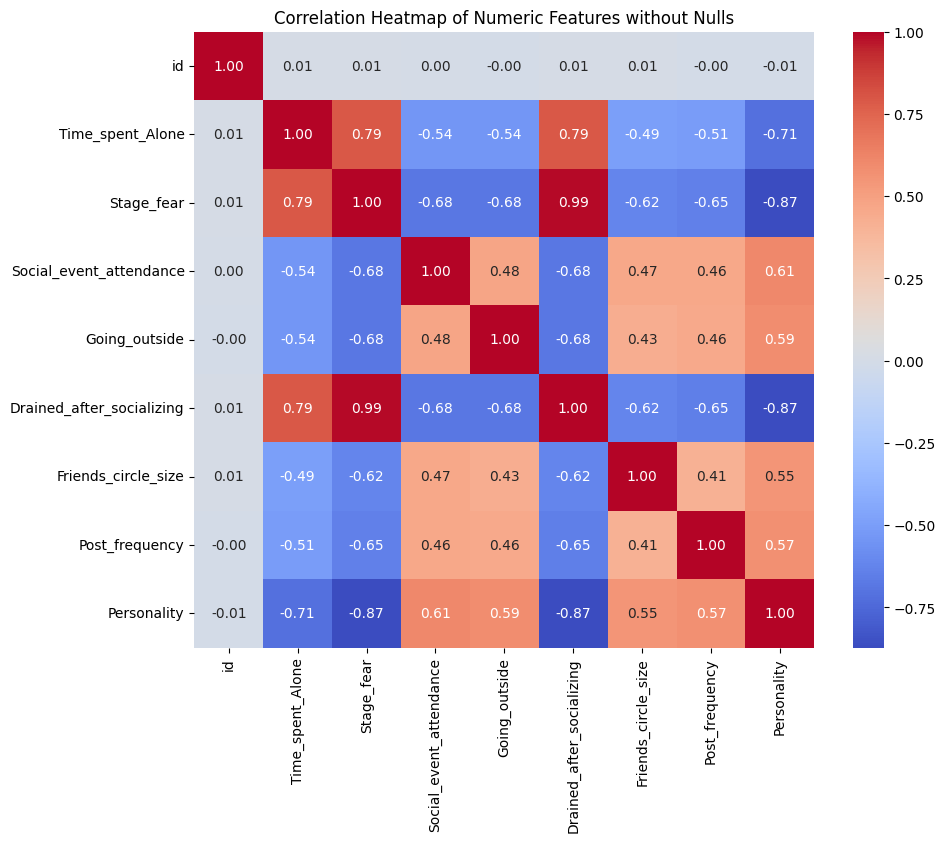

In [15]:
corr_nonulls = nonulls_df.corr()
heatmap_correlation(corr_nonulls, 'Numeric Features without Nulls')

## adding same replacement to test_df to check if correlation is the same

In [16]:
test_df = pd.read_csv('test.csv')
test_df.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
0,18524,3.00,No,7.00,4.00,No,6.00,NaN
1,18525,NaN,Yes,0.00,0.00,Yes,5.00,1.00
2,18526,3.00,No,5.00,6.00,No,15.00,9.00
3,18527,3.00,No,4.00,4.00,No,5.00,6.00
4,18528,9.00,Yes,1.00,2.00,Yes,1.00,1.00


In [17]:
# Replacing categorical values with numerical values in the test dataset
test_df['Stage_fear'] = test_df['Stage_fear'].replace({'Yes': 1, 'No': 0})
test_df['Drained_after_socializing'] = test_df['Drained_after_socializing'].replace({'Yes': 1, 'No': 0}) 

C:\Users\I748073\AppData\Local\Temp\ipykernel_32072\4260971225.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['Stage_fear'] = test_df['Stage_fear'].replace({'Yes': 1, 'No': 0})
C:\Users\I748073\AppData\Local\Temp\ipykernel_32072\4260971225.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['Drained_after_socializing'] = test_df['Drained_after_socializing'].replace({'Yes': 1, 'No': 0})


In [18]:
# Selecting numeric columns for correlation analysis
test_numeric_df = test_df.select_dtypes(include=['float64', 'int64'])
test_corr_matrix = test_numeric_df.corr()

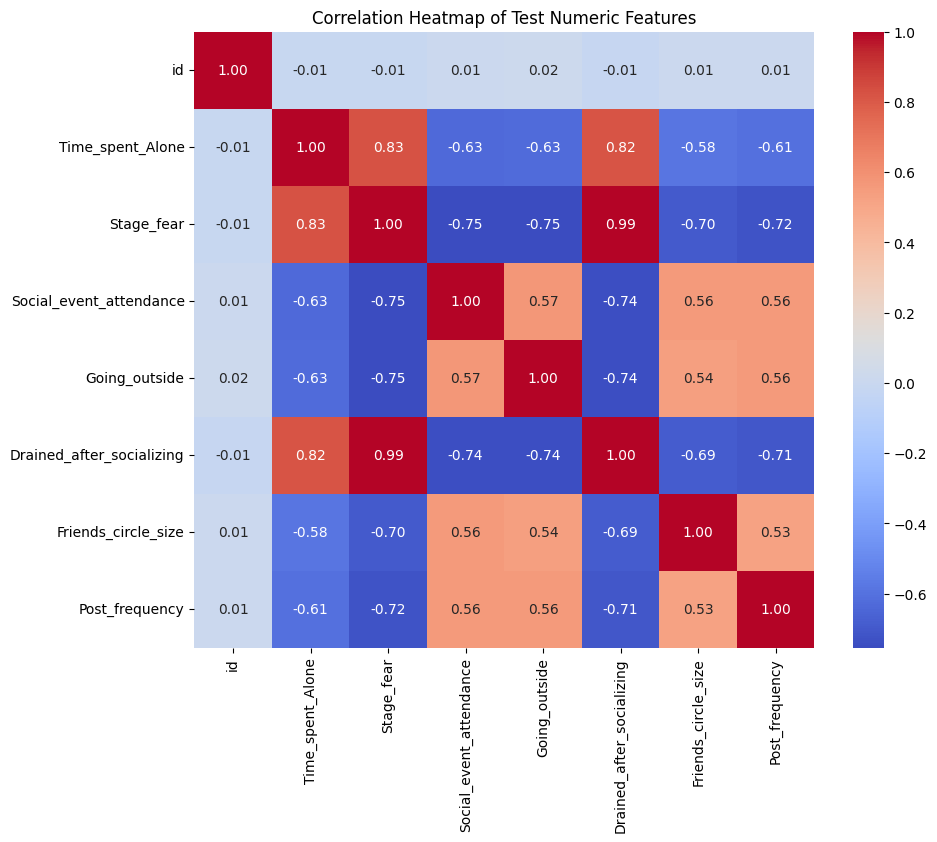

In [19]:
# Calling the function to plot the heatmap for test data
heatmap_correlation(test_corr_matrix, 'Test Numeric Features')

# Using linear regression to replace nulls

In [20]:
# Returning the personality column with labels
df['Personality'] = train_df['Personality'].replace({1: 'Extrovert', 0: 'Introvert'})

In [23]:
# Give an overall view of the data
# sns.pairplot(df, hue = 'Personality')

In [38]:
# Using linear legression to predict the nulls using
from sklearn.linear_model import LinearRegression

columns_to_impute = ['Stage_fear', 'Time_spent_Alone', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency', 'Social_event_attendance']

for col in columns_to_impute:
    null_replaced_df = fill_missing_column(numeric_df, col, exclude=['id', 'Personality'])

In [35]:
null_replaced_df.describe()
null_replaced_df.isnull().sum()

id                             0
Time_spent_Alone             212
Stage_fear                   221
Social_event_attendance      201
Going_outside                226
Drained_after_socializing    153
Friends_circle_size           17
Post_frequency               212
Personality                    0
dtype: int64

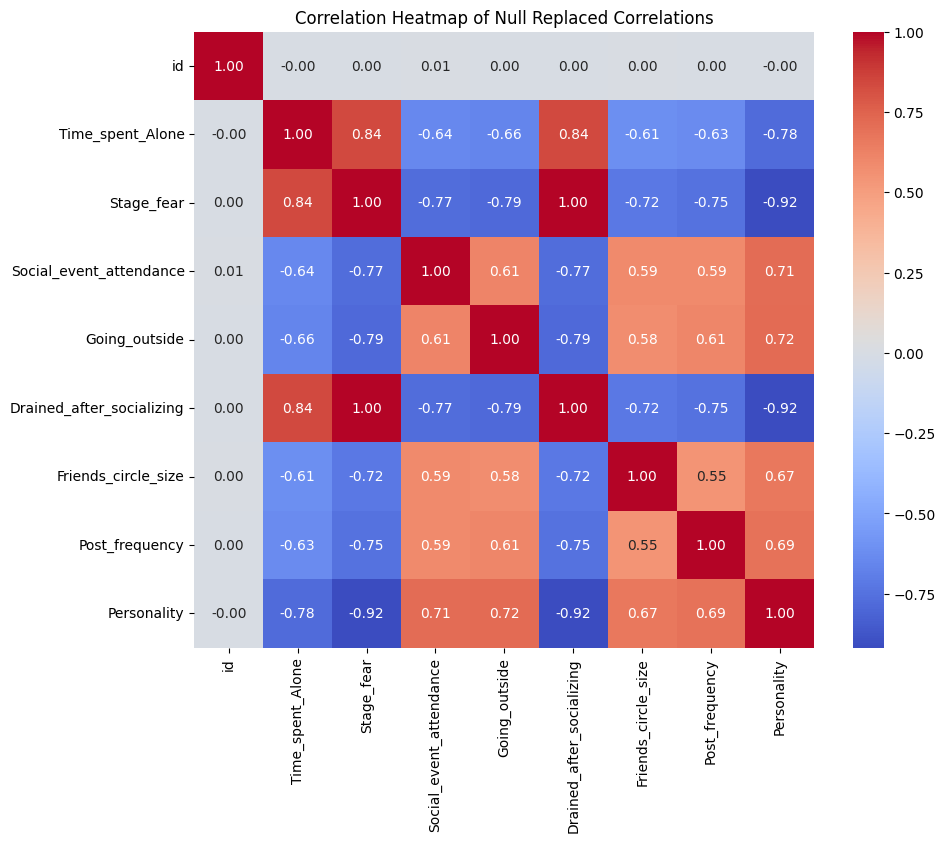

In [37]:
null_replaced_df.corr()
heatmap_correlation(null_replaced_df.corr(), 'Null Replaced Correlations')

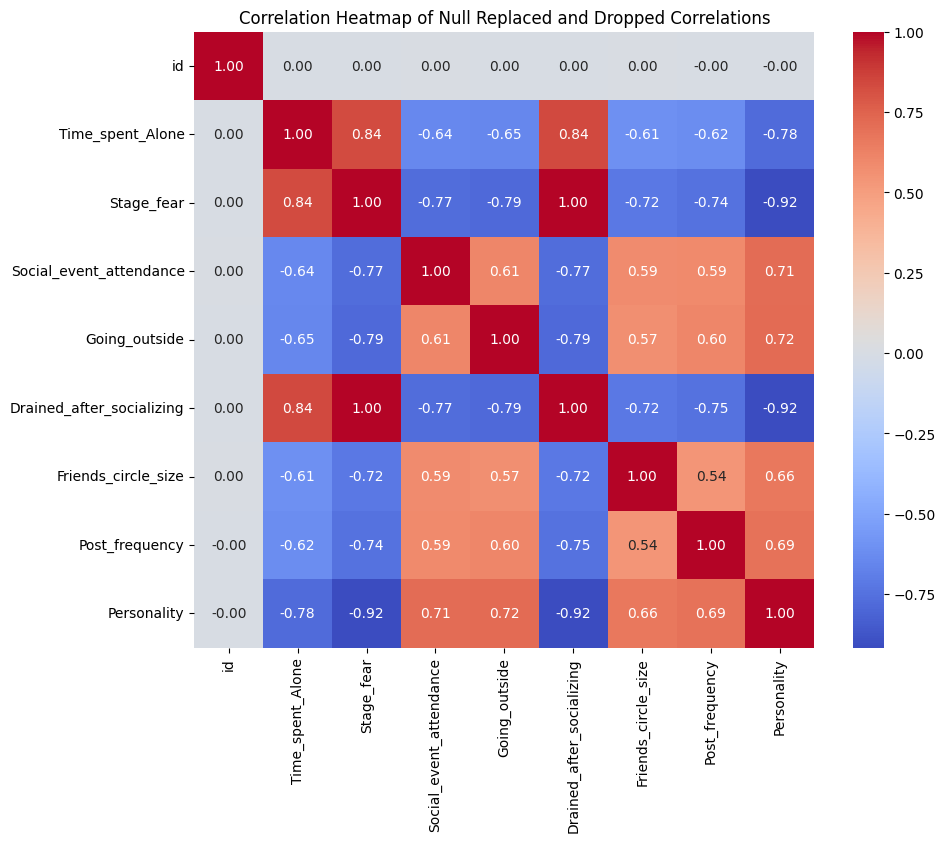

In [42]:
null_replaceddropped_df = null_replaced_df.dropna()
heatmap_correlation(null_replaceddropped_df.corr(), 'Null Replaced and Dropped Correlations')

In [44]:
null_replaceddropped_df.describe()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
count,17924.00,17924.00,17924.00,17924.00,17924.00,17924.00,17924.00,17924.00,17924.00
mean,9262.91,3.08,0.25,5.27,4.05,0.25,8.01,4.98,0.75
std,5344.16,2.95,0.43,2.72,2.03,0.43,4.17,2.84,0.43
min,0.00,0.00,-0.01,0.00,0.00,-0.01,0.00,0.00,0.00
25%,4638.75,1.00,0.00,3.00,3.00,0.00,5.00,3.00,0.00
50%,9258.50,2.00,0.00,6.00,4.00,0.00,8.00,5.00,1.00
75%,13882.25,4.00,0.01,7.00,6.00,0.01,11.00,7.00,1.00
max,18523.00,11.00,1.00,10.00,7.00,1.01,15.00,10.00,1.00
